# Champion (best-per-series) vs 60/40 Ensemble

Compares two production candidates on the final 5-year holdout (2019-2023):

| Strategy | What it does | Source |
|---|---|---|
| `champion` | per (country, indicator), fits whichever of the three backtested models (per-series ARIMA / ETS / shared-order ARIMA) won for that pair | `model/prediction/best_per_series.py` |
| `ensemble` | 60% ETS + 40% ARIMA blend on logit-transformed series (current production model) | `model/prediction/Ensemble_all_indicators.py` |
| `ets_only` | plain Holt ETS everywhere — baseline / sanity check | `model/old_models/exp_smoothing.py` |

**Why the champion is selected on an *earlier* window (no leakage).** If we
picked each pair's winner on 2019-2023 and then also scored it on 2019-2023,
the champion would win by construction — the selection would just be
cherry-picking the lowest of three MAEs per pair. Instead:

1. **Selection (inner) window:** the three candidate models are backtested on
   data up to 2018 only (train ≤ 2013, score 2014-2018) and the winner per
   pair is picked there.
2. **Evaluation (outer) window:** each strategy is fitted on data ≤ 2018 and
   scored on 2019-2023 — years neither the fits nor the champion's selection
   ever saw.

The inner selection is cached in
`data/intermediate/best_model_selection_inner.csv` (delete to force a re-run,
~20 min). Note this file differs from `best_model_selection.csv`, which is the
production selection made on the final window.

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / "notebooks"))

import notebooks.model_evaluation.eval_utils as eval_utils
from notebooks.model_evaluation.eval_utils import INDICATORS, TEST_YEARS, metrics
from model.old_models.arima import prepare_series
from model.old_models.exp_smoothing import fit_ets
from model.prediction.best_per_series import build_selection, extend_with_forecast
from model.prediction.Ensemble_all_indicators import forecast_ensemble

pd.set_option("display.float_format", "{:.4f}".format)

STRATEGY_LABELS = {
    "champion": "Champion (best per series)",
    "ensemble": "Ensemble 60/40 (production)",
    "ets_only": "ETS only",
}
STRATEGY_COLORS = {"champion": "#2a78d6", "ensemble": "#eb6834", "ets_only": "#1baf7a"}
ACTUAL_COLOR = "#0b0b0b"

INNER_SELECTION_PATH = ROOT / "data" / "intermediate" / "best_model_selection_inner.csv"

## Split the data and select the champion's winners (inner window)

In [2]:
df = pd.read_csv(ROOT / "data" / "data_preprocessed" / "processed_data.csv")
df = df.drop(columns=["Readiness", "Vulnerability"], errors="ignore")

last_years = df.groupby("Country")["Year"].transform("max")
df_train = df[df["Year"] <= last_years - TEST_YEARS].copy()   # <= 2018
df_test = df[df["Year"] > last_years - TEST_YEARS].copy()     # 2019-2023

print(f"train years <= {df_train['Year'].max()}, test years "
      f"{df_test['Year'].min()}-{df_test['Year'].max()}")

if INNER_SELECTION_PATH.exists():
    print(f"Loading cached inner selection: {INNER_SELECTION_PATH}")
    selection = pd.read_csv(INNER_SELECTION_PATH, keep_default_na=False)
else:
    print("Running the three-model backtest on the inner window (~20 min)...")
    selection = build_selection(df_train)   # selects winners on 2014-2018
    INNER_SELECTION_PATH.parent.mkdir(parents=True, exist_ok=True)
    selection.to_csv(INNER_SELECTION_PATH, index=False)

print("Inner-window winners per model:")
print(selection["model"].value_counts().to_string())

train years <= 2018, test years 2019-2023
Loading cached inner selection: /home/hugol/code/donismous/Climate-Resilience/data/intermediate/best_model_selection_inner.csv
Inner-window winners per model:
model
ets                   1228
arima                  533
arima_shared_order     471


## Forecast the outer window with each strategy

All three strategies are fitted on data ≤ 2018 and forecast 2019-2023.

In [3]:
# Champion: fit each pair's inner-window winner on the training data.
champ = extend_with_forecast(df_train, selection, end_year=int(df_test["Year"].max()))
champ_preds = (
    champ[champ["source"] == "forecast"]
    .rename(columns={"value": "predicted", "model": "fitted_model"})
    .assign(strategy="champion")
    [["country", "indicator", "year", "predicted", "strategy", "fitted_model"]]
)
print(f"champion forecasts: {len(champ_preds)} rows")
print(champ_preds["fitted_model"].value_counts().to_string())

/home/hugol/.pyenv/versions/3.12.9/envs/lewagon/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1490: ValueWarning: Matrix is singular. Using pinv.
  warnings.warn("Matrix is singular. Using pinv.", ValueWarning)


ARIMA(1, 0, 4) did not converge, falling back to ARIMA(1, 0, 0)
ARIMA(1, 0, 4) did not converge, falling back to ARIMA(1, 0, 0)


/home/hugol/.pyenv/versions/3.12.9/envs/lewagon/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1490: ValueWarning: Matrix is singular. Using pinv.
  warnings.warn("Matrix is singular. Using pinv.", ValueWarning)
/home/hugol/.pyenv/versions/3.12.9/envs/lewagon/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1490: ValueWarning: Matrix is singular. Using pinv.
  warnings.warn("Matrix is singular. Using pinv.", ValueWarning)


ARIMA(1, 0, 2) did not converge, falling back to ARIMA(1, 0, 0)


/home/hugol/.pyenv/versions/3.12.9/envs/lewagon/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1490: ValueWarning: Matrix is singular. Using pinv.
  warnings.warn("Matrix is singular. Using pinv.", ValueWarning)


...

ARIMA(1, 0, 4) did not converge, falling back to ARIMA(1, 0, 0)


/home/hugol/.pyenv/versions/3.12.9/envs/lewagon/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1490: ValueWarning: Matrix is singular. Using pinv.
  warnings.warn("Matrix is singular. Using pinv.", ValueWarning)
/home/hugol/.pyenv/versions/3.12.9/envs/lewagon/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1490: ValueWarning: Matrix is singular. Using pinv.
  warnings.warn("Matrix is singular. Using pinv.", ValueWarning)


ARIMA(1, 0, 2) did not converge, falling back to ARIMA(1, 0, 0)


/home/hugol/.pyenv/versions/3.12.9/envs/lewagon/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1490: ValueWarning: Matrix is singular. Using pinv.
  warnings.warn("Matrix is singular. Using pinv.", ValueWarning)
/home/hugol/.pyenv/versions/3.12.9/envs/lewagon/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1490: ValueWarning: Matrix is singular. Using pinv.
  warnings.warn("Matrix is singular. Using pinv.", ValueWarning)


champion forecasts: 11160 rows
fitted_model
ets                   6140
arima                 2665
arima_shared_order    2355


In [4]:
# Ensemble and ETS-only, per series on the same training data.
rows = []
countries = sorted(df_train["Country"].unique())
indicators = [c for c in INDICATORS if c in df_train.columns]

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    for i, country in enumerate(countries):
        if i % 20 == 0:
            print(f"{i + 1}/{len(countries)}: {country}")
        for indicator in indicators:
            try:
                train = prepare_series(df_train, country, indicator)
            except ValueError:
                continue
            years = list(range(train.index[-1].year + 1,
                               train.index[-1].year + 1 + TEST_YEARS))
            for strategy, fn in [
                ("ensemble", lambda s: forecast_ensemble(s, steps=TEST_YEARS)),
                ("ets_only", lambda s: fit_ets(s).forecast(TEST_YEARS).values),
            ]:
                try:
                    predicted = np.asarray(fn(train), dtype=float)
                    rows += [
                        {"country": country, "indicator": indicator, "year": y,
                         "predicted": p, "strategy": strategy, "fitted_model": strategy}
                        for y, p in zip(years, predicted)
                    ]
                except Exception as exc:
                    print(f"  {strategy} failed for {country}/{indicator}: {exc}")

other_preds = pd.DataFrame(rows)
preds = pd.concat([champ_preds, other_preds], ignore_index=True)
print(f"total forecast rows: {len(preds)}")

1/186: AFG
21/186: BLZ
41/186: CUB
61/186: GBR
81/186: ISL
101/186: LSO
121/186: MYS
141/186: QAT
161/186: SYR
181/186: VUT
total forecast rows: 33480


In [5]:
# Score against the outer-window actuals.
actuals = df_test.melt(id_vars=["Country", "Year"], value_vars=indicators,
                       var_name="indicator", value_name="actual").rename(
    columns={"Country": "country", "Year": "year"})
scored = preds.merge(actuals, on=["country", "indicator", "year"], how="inner")

results = (
    scored.assign(abs_err=lambda d: (d["predicted"] - d["actual"]).abs())
    .groupby(["country", "indicator", "strategy"])
    .agg(mae=("abs_err", "mean"),
         rmse=("abs_err", lambda e: np.sqrt((e ** 2).mean())))
    .reset_index()
)
print(f"scored pairs per strategy:")
print(results.groupby("strategy").size().to_string())

scored pairs per strategy:
strategy
champion    2232
ensemble    2232
ets_only    2232


## Results

In [6]:
overall = (
    results.groupby("strategy")[["mae", "rmse"]]
    .agg(["mean", "median"])
    .rename(index=STRATEGY_LABELS)
)
print("Overall on the 2019-2023 holdout (champion selected without seeing it):")
overall

Overall on the 2019-2023 holdout (champion selected without seeing it):


mae          rmse       
                              mean median   mean median
strategy                                               
Champion (best per series)  0.0143 0.0062 0.0158 0.0070
Ensemble 60/40 (production) 0.0128 0.0057 0.0141 0.0066
ETS only                    0.0144 0.0062 0.0159 0.0072

In [7]:
by_indicator = (
    results.groupby(["indicator", "strategy"])["mae"].mean().unstack()
    .rename(columns=STRATEGY_LABELS)
)

def highlight_winner(row):
    winner = row.idxmin()
    return ["background-color: lightgreen" if col == winner else "" for col in row.index]

print("Mean MAE per indicator (green = best strategy):")
by_indicator.style.apply(highlight_winner, axis=1).format("{:.6f}", na_rep="—")

Mean MAE per indicator (green = best strategy):


strategy,Champion (best per series),Ensemble 60/40 (production),ETS only
indicator,,,
Capacity,0.017360,0.016277,0.016503
Economic,0.024609,0.018804,0.025280
Ecosystems,0.003249,0.002686,0.002960
Exposure,0.000002,0.000000,0.000000
Food,0.010423,0.009706,0.010622
Governance,0.033304,0.030003,0.032890
Habitat,0.008242,0.007770,0.009131
Health,0.015530,0.013866,0.016697
Infrastructure,0.031540,0.028933,0.031134


In [8]:
pivot = results.pivot_table(index=["country", "indicator"], columns="strategy",
                            values="mae").dropna()

print(f"Three-way win rate over {len(pivot)} pairs:")
print(pivot.idxmin(axis=1).map(STRATEGY_LABELS).value_counts().to_string(), "\n")

h2h = np.where(pivot["champion"] < pivot["ensemble"], "champion",
               np.where(pivot["champion"] > pivot["ensemble"], "ensemble", "tie"))
print("Head-to-head champion vs ensemble:")
print(pd.Series(h2h).value_counts().to_string(), "\n")

# Did the champion's inner-window selection transfer? Compare it against
# always-ETS on the outer window:
h2h_ets = np.where(pivot["champion"] < pivot["ets_only"], "champion",
                   np.where(pivot["champion"] > pivot["ets_only"], "ets_only", "tie"))
print("Head-to-head champion vs plain ETS (did per-pair selection transfer?):")
print(pd.Series(h2h_ets).value_counts().to_string())

Three-way win rate over 2232 pairs:
Ensemble 60/40 (production)    864
ETS only                       696
Champion (best per series)     672 

Head-to-head champion vs ensemble:
ensemble    1285
champion     927
tie           20 

Head-to-head champion vs plain ETS (did per-pair selection transfer?):
ets_only    1150
champion    1046
tie           36


## Forecast plots — held-out window

Cross-country average per indicator: actuals (black) vs each strategy's
average forecast over 2019-2023.

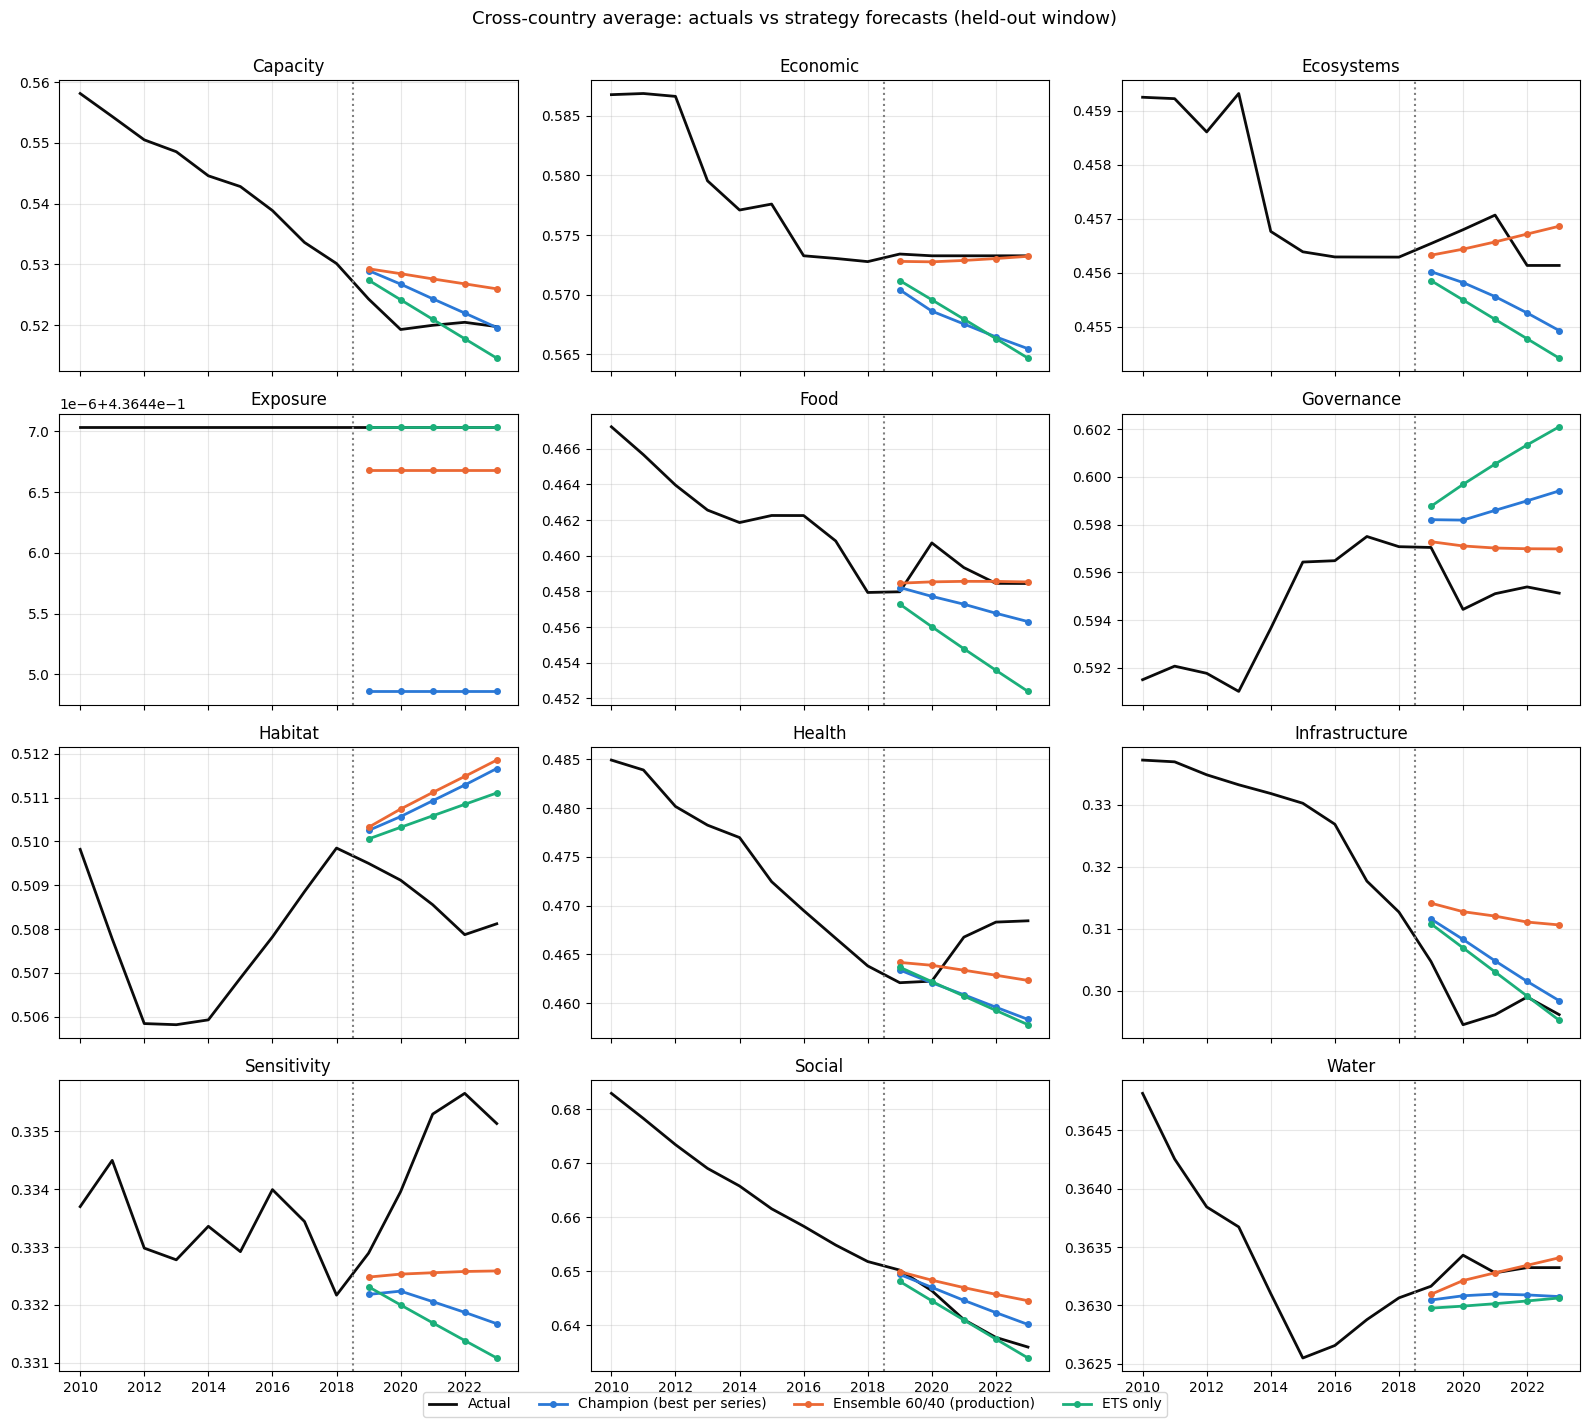

In [9]:
PLOT_FROM = 2010

actual_avg = (
    df[df["Year"] >= PLOT_FROM].groupby("Year")[indicators].mean()
)
pred_avg = preds.groupby(["strategy", "indicator", "year"])["predicted"].mean()
split_year = df_test["Year"].min() - 0.5

fig, axes = plt.subplots(4, 3, figsize=(16, 14), sharex=True)
for ax, indicator in zip(axes.flatten(), indicators):
    ax.plot(actual_avg.index, actual_avg[indicator],
            color=ACTUAL_COLOR, linewidth=2, label="Actual")
    for strategy, color in STRATEGY_COLORS.items():
        try:
            line = pred_avg.loc[strategy, indicator]
        except KeyError:
            continue
        ax.plot(line.index, line.values, color=color, linewidth=2,
                marker="o", markersize=4, label=STRATEGY_LABELS[strategy])
    ax.axvline(x=split_year, color="gray", linestyle=":", linewidth=1.5)
    ax.set_title(indicator)
    ax.grid(alpha=0.3)

handles, labels = axes.flatten()[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=4, fontsize=10,
           bbox_to_anchor=(0.5, -0.01))
fig.suptitle("Cross-country average: actuals vs strategy forecasts (held-out window)",
             y=1.0, fontsize=13)
plt.tight_layout()
plt.show()

### Country drill-down

Change the two constants and re-run.

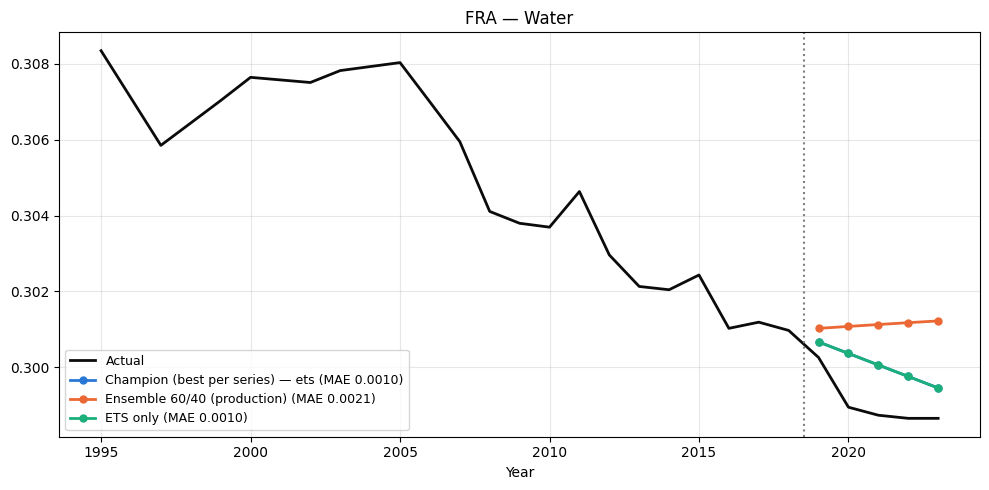

In [10]:
COUNTRY = "FRA"
INDICATOR = "Water"

history = df[df["Country"] == COUNTRY][["Year", INDICATOR]].dropna()
sub = preds[(preds["country"] == COUNTRY) & (preds["indicator"] == INDICATOR)]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(history["Year"], history[INDICATOR],
        color=ACTUAL_COLOR, linewidth=2, label="Actual")
for strategy, color in STRATEGY_COLORS.items():
    line = sub[sub["strategy"] == strategy].sort_values("year")
    if not len(line):
        continue
    mae = results[(results["country"] == COUNTRY) & (results["indicator"] == INDICATOR)
                  & (results["strategy"] == strategy)]["mae"]
    extra = f" — {line['fitted_model'].iloc[0]}" if strategy == "champion" else ""
    label = f"{STRATEGY_LABELS[strategy]}{extra}"
    if len(mae):
        label += f" (MAE {mae.iloc[0]:.4f})"
    ax.plot(line["year"], line["predicted"], color=color, linewidth=2,
            marker="o", markersize=5, label=label)
ax.axvline(x=split_year, color="gray", linestyle=":", linewidth=1.5)
ax.set_title(f"{COUNTRY} — {INDICATOR}")
ax.set_xlabel("Year")
ax.grid(alpha=0.3)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()